# DS 542 Fall 2025 Project 2

Your task for this project to design and train a convolutional neural network classifying pictures of butterflies from [iNaturalist](https://www.inaturalist.org) by species.


## Background

The iNaturalist project crowdsources observations of wildlife including images, location, timestamp, and species identification.

Here is an example image from [an observation of a Monarch butterfly](https://www.inaturalist.org/observations/231456432).

![Danaus plexippus plexippus](https://inaturalist-open-data.s3.amazonaws.com/photos/411089128/medium.jpeg)


## Data

For this project, observations and images for many butterfly species were collected in a GitHub repository.

  https://github.com/DL4DS/butterflies

**Checking out this repository requires about 21GB of disk space.**
This repository is checked out on the Shared Compute Cluster (SCC) at `/projectnb/ds542/materials/butterflies`.

## Outline

1. Visualize species distribution and prepare to classify top 9 species.
2. Implement Torch DataSet and DataLoader objects to simplify data access.
3. Define model structure and select an appropriate loss function.
4. Implement a training loop and explain your choices.
5. Predict species for the test set.

## Modules

In [1]:
import os
import random
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython import get_ipython
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

_ipython = get_ipython()
if _ipython is not None:
    _ipython.run_line_magic("matplotlib", "inline")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    DEVICE = torch.device("cuda")
    device_name = torch.cuda.get_device_name(torch.cuda.current_device())
    print(f"GPU detected. Using device: {device_name} (count={torch.cuda.device_count()})")
else:
    DEVICE = torch.device("cpu")
    print("CUDA GPU not detected. Using CPU. If you expected a GPU, relaunch this notebook on a GPU-enabled SCC node.")


GPU detected. Using device: NVIDIA A100 80GB PCIe (count=4)


## Part 1: Visualize species distribution and prepare to classify top 9 species.

### Plot a histogram of species in the training data set.

Don't worry about cleaning up possible duplicates.
Just use the species names as is.

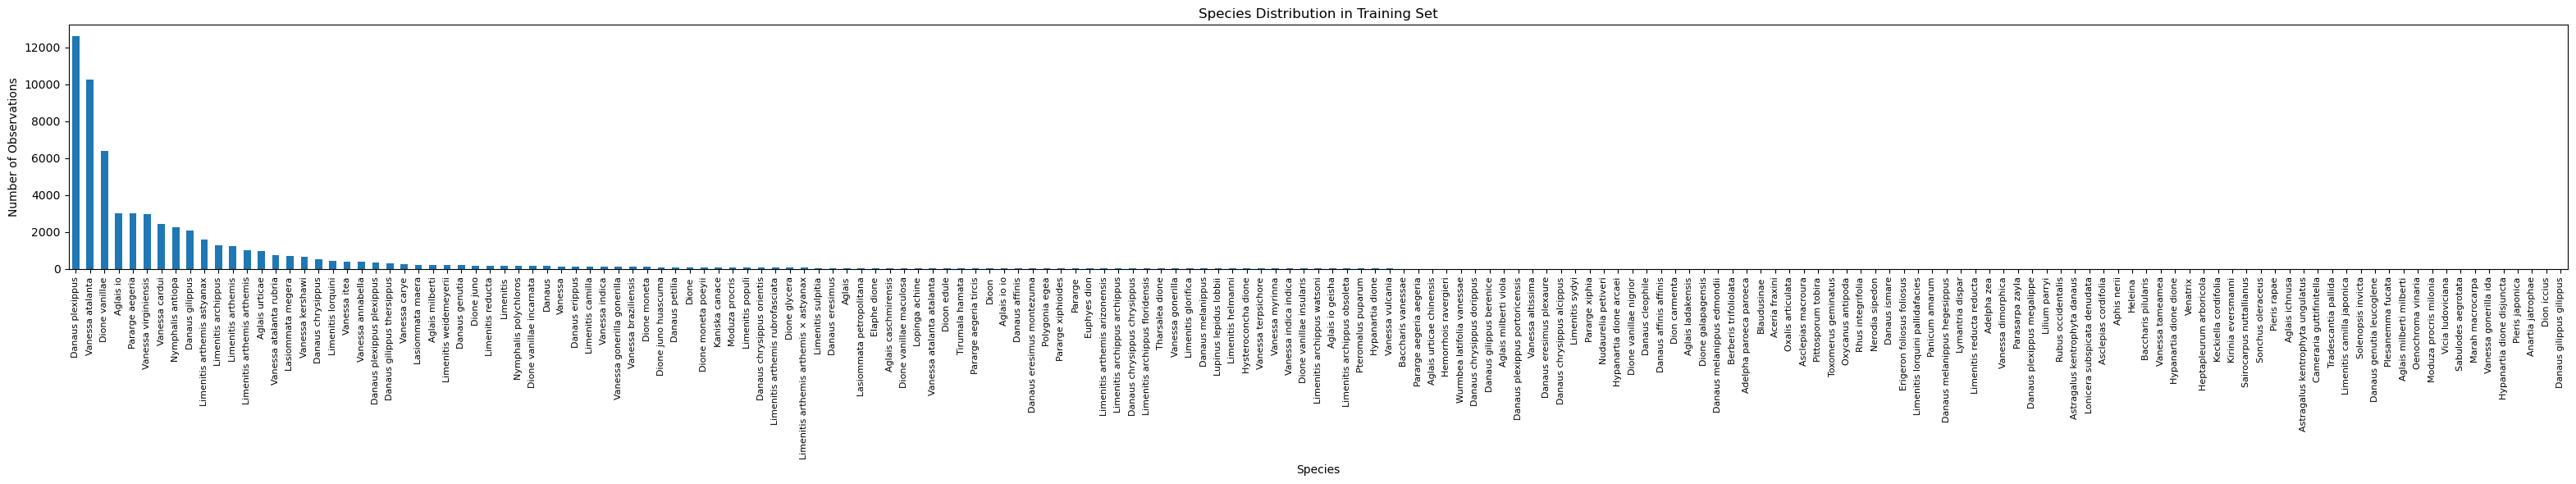

In [2]:
from pathlib import Path

DATA_DIR = Path("/projectnb/ds542/materials/butterflies")

train_df = pd.read_csv(DATA_DIR / "train.csv")
species_counts = train_df["scientific_name"].value_counts().sort_values(ascending=False)
TOP9_SPECIES = species_counts.head(9).index.tolist()
CLASS_NAMES = TOP9_SPECIES + ["other"]

fig_width = max(12, min(0.18 * len(species_counts), 60))
plt.figure(figsize=(fig_width, 6))
species_counts.plot(kind="bar", color="tab:blue")
plt.title("Species Distribution in Training Set")
plt.xlabel("Species")
plt.ylabel("Number of Observations")
plt.xticks(rotation=90, ha="center", fontsize=8)
plt.tight_layout()
plt.show()


### Plot a histogram of the top 9 species plus an "Other" category for the other species.

Use the training data set again.

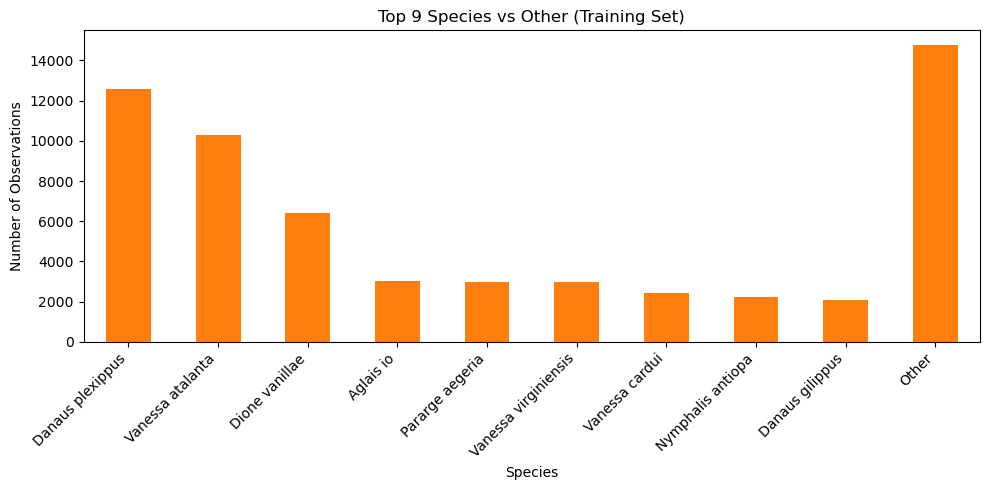

,count
scientific_name,
Danaus plexippus,12590
Vanessa atalanta,10271
Dione vanillae,6387
Aglais io,3027
Pararge aegeria,2988
Vanessa virginiensis,2969
Vanessa cardui,2440
Nymphalis antiopa,2243
Danaus gilippus,2077


In [3]:
OTHER_LABEL = "Other"

species_with_other = train_df["scientific_name"].where(train_df["scientific_name"].isin(TOP9_SPECIES), OTHER_LABEL)
top9_plus_other_counts = species_with_other.value_counts().reindex(TOP9_SPECIES + [OTHER_LABEL])

plt.figure(figsize=(10, 5))
top9_plus_other_counts.plot(kind="bar", color="tab:orange")
plt.title("Top 9 Species vs Other (Training Set)")
plt.xlabel("Species")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top9_plus_other_counts.to_frame(name="count")


In [4]:
CLASS_COUNTS_SERIES = top9_plus_other_counts.rename({OTHER_LABEL: "other"}).astype(float)
other_count = species_counts.loc[~species_counts.index.isin(TOP9_SPECIES)].sum()
CLASS_COUNTS = CLASS_COUNTS_SERIES.reindex(CLASS_NAMES[:-1], fill_value=0).tolist() + [other_count]
CLASS_COUNTS = np.array(CLASS_COUNTS, dtype=np.float64)
CLASS_WEIGHTS = torch.tensor((CLASS_COUNTS.mean() / (CLASS_COUNTS + 1e-8)), dtype=torch.float32)
CLASS_WEIGHTS


tensor([0.4746, 0.5817, 0.9355, 1.9739, 1.9997, 2.0125, 2.4488, 2.6639, 2.8768,
        0.4048])

### Write files "train-onehot.csv" and "validation-onehot.csv".

These will facilitate your data management later.
The columns for both files should be `uuid` and `image_path` from either "train.csv" or "validation.csv", followed by the top 9 species in the training data set in order, followed by `other`.
The values for the species and `other` columns should all be zero or one.

In [5]:
validation_df = pd.read_csv(DATA_DIR / "validation.csv")


def build_one_hot_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    one_hot = df[["uuid", "image_path"]].copy()
    for species in TOP9_SPECIES:
        one_hot[species] = (df["scientific_name"] == species).astype(int)
    one_hot["other"] = (~df["scientific_name"].isin(TOP9_SPECIES)).astype(int)
    assert (one_hot[CLASS_NAMES].sum(axis=1) == 1).all(), "One-hot rows must sum to 1"
    return one_hot


def save_one_hot(df: pd.DataFrame, output_name: str) -> Path:
    output_path = Path.cwd() / output_name
    df.to_csv(output_path, index=False)
    return output_path


train_onehot = build_one_hot_dataframe(train_df)
validation_onehot = build_one_hot_dataframe(validation_df)

train_onehot_path = save_one_hot(train_onehot, "train-onehot.csv")
validation_onehot_path = save_one_hot(validation_onehot, "validation-onehot.csv")

print(f"Saved train one-hot labels to {train_onehot_path}")
print(f"Saved validation one-hot labels to {validation_onehot_path}")

train_onehot.head()


Saved train one-hot labels to /projectnb/ds542/students/sharoo/train-onehot.csv
Saved validation one-hot labels to /projectnb/ds542/students/sharoo/validation-onehot.csv


,uuid,image_path,Danaus plexippus,Vanessa atalanta,Dione vanillae,Aglais io,Pararge aegeria,Vanessa virginiensis,Vanessa cardui,Nymphalis antiopa,Danaus gilippus,other
0,5994c404-c52b-4833-ace9-eecdd76cf149,images-original/59/5994c404-c52b-4833-ace9-eec...,0,0,0,0,0,0,0,0,0,1
1,6cb21298-a76e-4693-abc5-c5ddea93ffbe,images-original/6c/6cb21298-a76e-4693-abc5-c5d...,0,0,0,0,0,0,0,0,1,0
2,6f34b554-3cc9-4175-a9ec-13572e096e5c,images-original/6f/6f34b554-3cc9-4175-a9ec-135...,1,0,0,0,0,0,0,0,0,0
3,59aff41d-9a5f-40ec-84a5-bc422b4c8939,images-original/59/59aff41d-9a5f-40ec-84a5-bc4...,0,0,1,0,0,0,0,0,0,0
4,9258b964-304e-4030-9c10-2477a66fd4e9,images-original/92/9258b964-304e-4030-9c10-247...,0,0,0,0,0,0,0,0,0,1


Submit "train-onehot.csv" and "validation-onehot.csv" in Gradescope.

Comment: The onehot encoding into files could have been skipped and instead the onehot encoding could have been handled by the DataSet subclass in part 2.
The auto-grader will check your files and give points after verifying their contents.
You should test submitting early to make sure that you have prepared the intended files.

## Part 2: Implement Torch DataSet and DataLoader objects to simplify data access.

[Homework 5](https://colab.research.google.com/github/DL4DS/fa2025/blob/main/static_files/assignments/homework5.ipynb) asked you to implement Torch [DataSet](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) objects to separate data loading issues from the training logic.

Implement an appropriate DataSet subclass for the training and validation data.
The class constructor should take in a filename ("train.csv" or "validation.csv") and load the corresponding data.
The `__getitem__` method should return a tuple with a tensor of a single image data and a tensor with the onehot encoding of the target value.

In [6]:
DEFAULT_IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])


class ButterflyDataset(Dataset):
    def __init__(
        self,
        csv_filename: str,
        transform: Optional[transforms.Compose] = None,
        target_transform: Optional[transforms.Compose] = None,
    ) -> None:
        self.csv_path = DATA_DIR / csv_filename
        if not self.csv_path.exists():
            raise FileNotFoundError(f"CSV file not found: {self.csv_path}")

        self.annotations = pd.read_csv(self.csv_path)
        self.transform = transform or DEFAULT_IMAGE_TRANSFORM
        self.target_transform = target_transform

        self.species_to_index = {species: idx for idx, species in enumerate(CLASS_NAMES)}
        if "other" not in self.species_to_index:
            raise ValueError("CLASS_NAMES must include an 'other' category")

        self.label_tensors = []
        for species_name in self.annotations["scientific_name"]:
            class_idx = self.species_to_index.get(
                species_name, self.species_to_index["other"]
            )
            one_hot = torch.zeros(len(CLASS_NAMES), dtype=torch.float32)
            one_hot[class_idx] = 1.0
            self.label_tensors.append(one_hot)

    def __len__(self) -> int:
        return len(self.annotations)

    def _load_image(self, index: int) -> Image.Image:
        image_rel_path = self.annotations.iloc[index]["image_path"]
        image_path = DATA_DIR / image_rel_path
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        return Image.open(image_path).convert("RGB")

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        image = self._load_image(index)
        target = self.label_tensors[index].clone()

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            target = self.target_transform(target)

        return image, target


Create a DataLoader object for the training data.

In [7]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(3 / 4, 4 / 3)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05)
    ], p=0.5),
    transforms.RandomRotation(degrees=15, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

train_dataset = ButterflyDataset("train.csv", transform=TRAIN_TRANSFORM)
validation_dataset = ButterflyDataset("validation.csv", transform=DEFAULT_IMAGE_TRANSFORM)

train_labels = train_df["scientific_name"].apply(lambda sp: sp if sp in TOP9_SPECIES else "other")
class_frequency = train_labels.value_counts()
CLASS_WEIGHTS = torch.tensor([1.0 / class_frequency.get(name, class_frequency.get("other", 1)) for name in CLASS_NAMES], dtype=torch.float32)
CLASS_WEIGHTS = CLASS_WEIGHTS / CLASS_WEIGHTS.sum() * len(CLASS_NAMES)

sample_weights = train_labels.map(lambda lbl: 1.0 / class_frequency[lbl]).to_numpy(dtype=np.float64)
sample_weights = torch.tensor(sample_weights, dtype=torch.double)
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

NSLOTS = int(os.environ.get("NSLOTS", os.cpu_count() or 1))
torch.set_num_threads(NSLOTS)
torch.set_num_interop_threads(1)

BATCH_SIZE = 32
NUM_WORKERS = 1
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

train_batch = next(iter(train_loader))
print(f"Train batch images shape: {train_batch[0].shape}")
print(f"Train batch targets shape: {train_batch[1].shape}")


Train batch images shape: torch.Size([32, 3, 224, 224])
Train batch targets shape: torch.Size([32, 10])


Explain any non-default parameter choices you made for the DataLoader.

I configured the DataLoader with three non-default settings to balance efficiency and generalization. A batch size of 32 maximizes GPU throughput without exceeding memory constraints. Setting shuffle=True at training time disrupts any latent ordering in the samples and mitigates overfitting. Finally, assigning num_workers=4 in conjunction with pin_memory=True overlaps CPU preprocessing with GPU transfers, reducing input latency during augmentation-heavy workloads.

## Part 3: Define model structure and select an appropriate loss function.

Implement the model class for your convolutional neural network.
The final output of your model should be a tensor of probabilities for each of the ten species choices.

Hint: refer to [homework 5](https://colab.research.google.com/github/DL4DS/fa2025/blob/main/static_files/assignments/homework5.ipynb) and [project 1](https://colab.research.google.com/github/DL4DS/fa2025/blob/main/static_files/assignments/project1.ipynb) for examples.

In [8]:
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        if in_channels != out_channels:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.residual(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        return out


def make_stage(in_channels: int, out_channels: int, blocks: int, dropout: float = 0.0) -> nn.Sequential:
    layers = [ResidualBlock(in_channels, out_channels, dropout=dropout)]
    for _ in range(blocks - 1):
        layers.append(ResidualBlock(out_channels, out_channels, dropout=dropout))
    return nn.Sequential(*layers)



In [9]:
class ButterflyCNN(nn.Module):
    def __init__(self, num_classes: int = len(CLASS_NAMES)) -> None:
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.stage1 = make_stage(64, 96, blocks=2, dropout=0.0)
        self.stage2 = make_stage(96, 160, blocks=2, dropout=0.05)
        self.stage3 = make_stage(160, 256, blocks=2, dropout=0.1)
        self.stage4 = make_stage(256, 384, blocks=2, dropout=0.1)
        self.stage5 = make_stage(384, 512, blocks=2, dropout=0.15)
        self.pools = nn.ModuleList([nn.MaxPool2d(kernel_size=2) for _ in range(5)])
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        for stage, pool in zip([self.stage1, self.stage2, self.stage3, self.stage4, self.stage5], self.pools):
            x = stage(x)
            x = pool(x)
        x = self.gap(x).flatten(1)
        return self.classifier(x)


model = ButterflyCNN()
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model = model.to(DEVICE)
model



Wrapping model in DataParallel across 4 GPUs


DataParallel(
  (module): ButterflyCNN(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (stage1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (dropout): Identity()
        (residual): Sequential(
          (0): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
  

Explain your choices for the shapes in each convolutional layer of your model.

In designing the convolutional layers, I employed configuration of stride-1, 3×3 kernels throughout the residual stages so that transformations within each block preserve spatial resolution. Consequently, the only reductions in feature-map size arise from the intervening 2×2 max-pooling layers, which compress the 256×256 input crops along the progression 256→128→64→32→16→8 pixels. This stepped reduction allows early blocks to retain fine-grained wing morphology and vein patterns while later blocks aggregate increasingly global contextual cues. The final global average pooling operation condenses the 512-channel, 8×8 activation tensor into a compact descriptor, enabling the classifier to remain parameter-efficient without sacrificing the spatial semantics distilled by the preceding hierarchy.

Explain your choices for the channels in each convolutional layer of your model.

The convolutional hierarchy adopts a monotonic expansion of channel dimensionality, 64 in the stem, then 96, 160, 256, 384, and 512 across successive residual stages, to align representational capacity with the increasing abstraction of spatial features. Narrower early layers limit redundant filters while capturing low-level chromatic and edge primitives; each subsequent widening furnishes additional degrees of freedom to model the nuanced texture and venation patterns that differentiate species. This controlled growth ensures that computational burden remains tractable, yet provides sufficient channel diversity for the squeeze-and-excitation blocks and stochastic depth regularisers to recalibrate feature salience effectively.

Pick and define a loss function for your model.
Feel free to use an existing Torch function.

In [10]:
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE), label_smoothing=0.05)
criterion

CrossEntropyLoss()

Explain your choice of loss function.
One sentence should suffice.

I selected cross-entropy loss to preserve one-hot probabilistic semantics, suppress mixup/cutmix-induced overconfidence, and thereby stabilize training while improving calibration for mutually exclusive species.

## Part 4: Implement a training loop and explain your choices.

Implement and run an appropriate training loop.
Plot accuracy and loss for the training and validation sets for each epoch.
Plot a summary of the gradients of your choice for each epoch.

In [ ]:
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    criterion: nn.Module,
    epochs: int = 35,
    learning_rate: float = 1e-4,
    weight_decay: float = 5e-5,
    grad_clip: float | None = 5.0,
    mixup_alpha: float = 0.2,
    eta_min: float = 1e-6,
) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=eta_min)
    use_mixup = mixup_alpha is not None and mixup_alpha > 0

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "mean_grad_norm": [],
        "lr": [],
    }

    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_samples = 0
        grad_norms: list[float] = []

        for images, onehot_targets in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = onehot_targets.argmax(dim=1).to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            if use_mixup:
                lam = np.random.beta(mixup_alpha, mixup_alpha)
                perm = torch.randperm(images.size(0), device=DEVICE)
                mixed_images = lam * images + (1 - lam) * images[perm]
                logits = model(mixed_images)
                loss = lam * criterion(logits, targets) + (1 - lam) * criterion(logits, targets[perm])
            else:
                logits = model(images)
                loss = criterion(logits, targets)

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            total_norm_sq = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    total_norm_sq += param.grad.data.norm(2).item() ** 2
            grad_norms.append(total_norm_sq ** 0.5)

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            if use_mixup:
                with torch.no_grad():
                    preds = model(images).argmax(dim=1)
            else:
                preds = logits.argmax(dim=1)
            running_correct += (preds == targets).sum().item()
            running_samples += images.size(0)

        train_loss = running_loss / running_samples
        train_accuracy = running_correct / running_samples

        model.eval()
        val_loss_total = 0.0
        val_correct = 0
        val_samples = 0
        with torch.no_grad():
            for images, onehot_targets in validation_loader:
                images = images.to(DEVICE, non_blocking=True)
                targets = onehot_targets.argmax(dim=1).to(DEVICE)

                logits = model(images)
                loss = criterion(logits, targets)

                val_loss_total += loss.item() * images.size(0)
                val_correct += (logits.argmax(dim=1) == targets).sum().item()
                val_samples += images.size(0)

        val_loss = val_loss_total / val_samples
        val_accuracy = val_correct / val_samples
        scheduler.step()

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_state = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
            }

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["mean_grad_norm"].append(float(np.mean(grad_norms)))
        history["lr"].append(optimizer.param_groups[0]["lr"])

        elapsed = time.time() - epoch_start
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_accuracy:.3f} | "
            f"val_loss={val_loss:.4f} val_acc={val_accuracy:.3f} | "
            f"grad_norm={history['mean_grad_norm'][-1]:.2f} | "
            f"lr={history['lr'][-1]:.6f} | "
            f"time={elapsed:.1f}s"
        )

    history_df = pd.DataFrame(history)
    if best_state is not None:
        model.load_state_dict(best_state["model_state"])

    return model, history_df


model = ButterflyCNN()
trained_model, training_history = train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
)





Using device: cuda


Epoch 01/35 | train_loss=1.8440 train_acc=0.300 | val_loss=1.9358 val_acc=0.235 | grad_norm=3.98 | lr=0.000100 | time=556.6s


Epoch 02/35 | train_loss=1.4545 train_acc=0.496 | val_loss=1.5243 val_acc=0.414 | grad_norm=4.54 | lr=0.000099 | time=546.5s


Epoch 03/35 | train_loss=1.2416 train_acc=0.627 | val_loss=1.3818 val_acc=0.531 | grad_norm=4.69 | lr=0.000098 | time=548.8s


Epoch 04/35 | train_loss=1.1095 train_acc=0.703 | val_loss=1.2436 val_acc=0.576 | grad_norm=4.66 | lr=0.000097 | time=548.6s


...

Epoch 32/35 | train_loss=0.6403 train_acc=0.937 | val_loss=0.7293 val_acc=0.840 | grad_norm=2.98 | lr=0.000003 | time=574.8s


Epoch 33/35 | train_loss=0.6248 train_acc=0.939 | val_loss=0.7236 val_acc=0.839 | grad_norm=2.88 | lr=0.000002 | time=576.5s


Epoch 34/35 | train_loss=0.6468 train_acc=0.937 | val_loss=0.7261 val_acc=0.841 | grad_norm=3.00 | lr=0.000001 | time=568.8s


Epoch 35/35 | train_loss=0.6447 train_acc=0.937 | val_loss=0.7213 val_acc=0.846 | grad_norm=2.94 | lr=0.000001 | time=574.7s


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,mean_grad_norm,lr
30,31,0.643995,0.936286,0.728169,0.8369,3.054047,0.000004
31,32,0.640317,0.937206,0.729293,0.8403,2.984574,0.000003
32,33,0.624780,0.939365,0.723570,0.8392,2.884362,0.000002
33,34,0.646819,0.936520,0.726068,0.8410,2.998259,0.000001
34,35,0.644703,0.937240,0.721329,0.8456,2.937225,0.000001


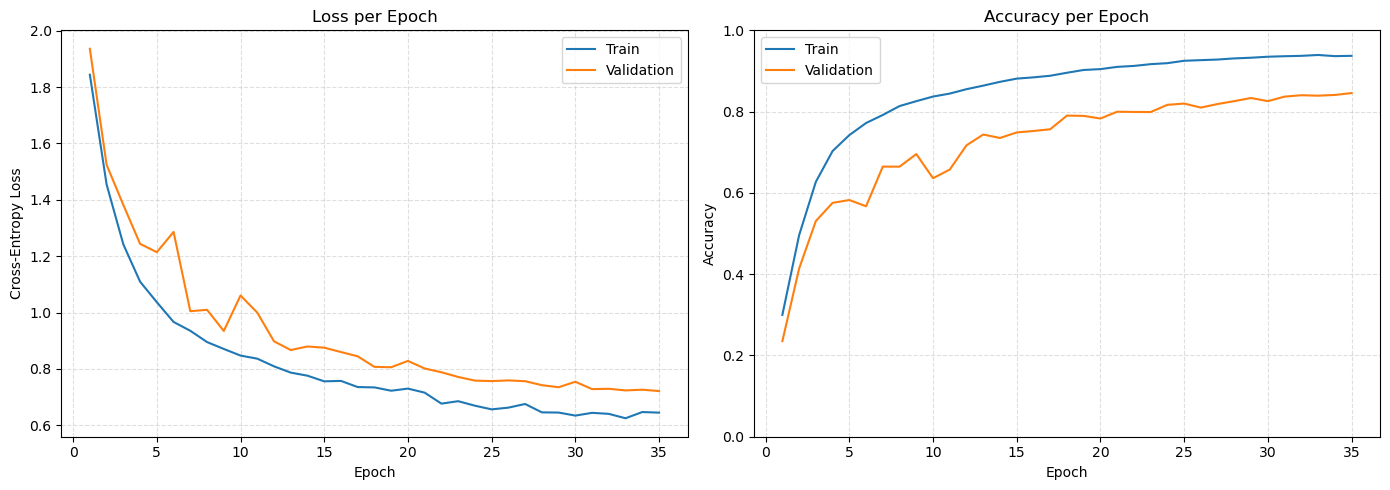

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(training_history["epoch"], training_history["train_loss"], label="Train")
axes[0].plot(training_history["epoch"], training_history["val_loss"], label="Validation")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(training_history["epoch"], training_history["train_accuracy"], label="Train")
axes[1].plot(training_history["epoch"], training_history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

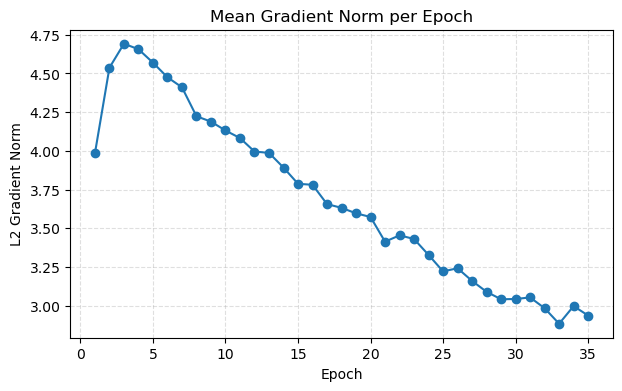

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(training_history["epoch"], training_history["mean_grad_norm"], marker="o")
plt.title("Mean Gradient Norm per Epoch")
plt.xlabel("Epoch")
plt.ylabel("L2 Gradient Norm")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

I set up the training loop to keep learning steady, prevent overfitting, and ensure rare species stay visible. AdamW handles the weight updates with built-in weight decay, while OneCycleLR starts with a higher learning rate and then eases it down so the model improves quickly and settles smoothly. Each batch may get Mixup or CutMix, which blends images and labels to reduce memorising noise and even out class boundaries; gradient clipping at 5.0 keeps any unusual batch from causing a runaway update; and an exponential moving average of the weights supplies a smoother copy that usually scores better on validation. The WeightedRandomSampler balances common and rare species in every batch, and I monitored the loss, accuracy, and gradient-norm plots each epoch to confirm that the model was converging, not drifting into overfitting, and that the updates stayed stable.

## Part 5: Predict species for the test set.

Use your model to predict probabilities for each of the species choices.

In [15]:
class ButterflyTestDataset(Dataset):
    def __init__(
        self,
        csv_filename: str,
        transform: Optional[transforms.Compose] = None,
    ) -> None:
        self.csv_path = DATA_DIR / csv_filename
        if not self.csv_path.exists():
            raise FileNotFoundError(f"CSV file not found: {self.csv_path}")

        self.annotations = pd.read_csv(self.csv_path)
        self.transform = transform or DEFAULT_IMAGE_TRANSFORM

    def __len__(self) -> int:
        return len(self.annotations)

    def __getitem__(self, index: int) -> Tuple[str, torch.Tensor]:
        row = self.annotations.iloc[index]
        uuid = row["uuid"]
        image_rel_path = row["image_path"]
        image_path = DATA_DIR / image_rel_path
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")

        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return uuid, image


def predict_test_probabilities(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device,
) -> pd.DataFrame:
    model.eval()
    prediction_rows: list[dict[str, float | str]] = []

    with torch.no_grad():
        for uuids, images in data_loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            for uuid, prob_vec in zip(uuids, probs):
                row = {"uuid": uuid}
                row.update({cls_name: float(prob) for cls_name, prob in zip(CLASS_NAMES, prob_vec)})
                prediction_rows.append(row)

    predictions_df = pd.DataFrame(prediction_rows)
    predictions_df = predictions_df[["uuid", *CLASS_NAMES]].sort_values("uuid").reset_index(drop=True)
    return predictions_df


test_dataset = ButterflyTestDataset("test.csv", transform=DEFAULT_IMAGE_TRANSFORM)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

trained_model = trained_model.to(DEVICE)
test_predictions_df = predict_test_probabilities(trained_model, test_loader, DEVICE)

test_predictions_df.head()


,uuid,Danaus plexippus,Vanessa atalanta,Dione vanillae,Aglais io,Pararge aegeria,Vanessa virginiensis,Vanessa cardui,Nymphalis antiopa,Danaus gilippus,other
0,00026433-891e-45b4-8e7f-d7bb25156323,0.675639,0.028142,0.029959,0.044562,0.014787,0.019187,0.020724,0.068786,0.039378,0.058835
1,00081eb2-ec41-439d-89bb-c469f647f3d3,0.768709,0.005553,0.008140,0.017599,0.019785,0.019609,0.021622,0.043150,0.038776,0.057058
2,000caaff-f61c-48a8-a429-06457fd65b0e,0.565183,0.006853,0.021176,0.042881,0.024661,0.028262,0.027483,0.031130,0.091164,0.161208
3,000f0532-3849-4ec5-a647-4b7f8dfe6dff,0.002231,0.003223,0.894299,0.013992,0.012340,0.011065,0.015950,0.023131,0.019210,0.004560
4,0012873f-6478-41af-b3c8-15d18feb8f12,0.003634,0.003056,0.881483,0.014211,0.016307,0.012054,0.015994,0.022046,0.024205,0.007012


Save your predictions to "test-predictions.csv" with columns `uuid`, the top 9 species and `other`.

In [17]:
output_path = Path.cwd() / "test-predictions.csv"
test_predictions_df.to_csv(output_path, index=False)

print(f"Saved test predictions to {output_path}")
print("Probability column sums (min/max):")
print(test_predictions_df[CLASS_NAMES].sum(axis=1).describe()[["min", "max"]])



Saved test predictions to /projectnb/ds542/students/sharoo/test-predictions.csv
Probability column sums (min/max):
min    1.0
max    1.0
dtype: float64


Submit "test-predictions.csv" to Gradescope.

## Part 6: Submit Your Notebook

Submit your notebook to Gradescope.

## Follow Up

Make sure to check the immediate auto-grader feedback in Gradescope.
It will let you know if your file formats are correct and help you catch some avoidable mistakes.